## Fine-tuning Qwen3.5 (Vision-Language Model) on Google Colab

This notebook fine-tunes Qwen3.5 to convert images of handwritten/printed math formulas into LaTeX code. It also includes **before vs. after fine-tuning evaluation metrics**, **training visualizations**, and packages everything needed to build a **Streamlit demo app** at the end.

### Installation

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
    !uv pip install -qqq --no-deps "torchcodec==0.7.0"

elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth

!uv pip install --upgrade --no-deps "tokenizers>=0.22.0,<=0.23.0" trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0
import torch
if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
    !uv pip install --no-deps "apache-tvm-ffi==0.1.9" "tilelang==0.1.8"
else:
    os.environ["FLA_TILELANG"] = "0"
!uv pip install --no-deps --upgrade "torchao>=0.16.0"

# --- Extra packages for evaluation metrics + visualizations + Streamlit packaging ---
!uv pip install -qqq jiwer nltk matplotlib pandas


### Downloading and Loading the Model

In [2]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.2: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)


<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

In [4]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")


README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [5]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

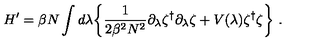

In [6]:
dataset[2]["image"]

In [7]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

We can also render the LaTeX in the browser directly!

In [8]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))


<IPython.core.display.Math object>

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [9]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass


Let's convert the dataset into the "correct" format for finetuning:

In [10]:
# We reserve a small held-out evaluation set that is NOT used for training.
# This lets us fairly compare the base model vs. the fine-tuned model on unseen samples,
# which is exactly the "before vs after fine-tuning" comparison you'd want to showcase.
EVAL_SIZE = 30  # number of held-out samples used purely for evaluation

train_samples = dataset.select(range(len(dataset) - EVAL_SIZE))
eval_samples  = dataset.select(range(len(dataset) - EVAL_SIZE, len(dataset)))

converted_dataset = [convert_to_conversation(sample) for sample in train_samples]

print(f"Training samples : {len(train_samples)}")
print(f"Held-out eval samples : {len(eval_samples)}")


Training samples : 68656
Held-out eval samples : 30


We look at how the conversations are structured for the first example:

In [11]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

### Evaluation Helper Functions

Before touching the model, let's define reusable helper functions:
- `generate_latex(...)` — runs the model on an image and returns the predicted LaTeX string (no streaming, so we can capture it programmatically).
- `char_error_rate(...)` — Character Error Rate (CER), a standard OCR/LaTeX-OCR metric (lower is better).
- `evaluate_on_samples(...)` — runs the model over the held-out `eval_samples` and reports CER, exact-match accuracy, and BLEU.

These are what we'll use to produce concrete **before vs. after fine-tuning numbers** for your resume/portfolio.

In [12]:
import time
import numpy as np
import pandas as pd
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

import nltk
nltk.download("punkt", quiet = True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4


def generate_latex(model, tokenizer, image, instruction = "Write the LaTeX representation for this image.", max_new_tokens = 128):
    """Runs inference on a single image and returns the predicted LaTeX string (no streaming)."""
    FastVisionModel.for_inference(model)
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")

    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens = max_new_tokens,
            use_cache = True, temperature = 1.5, min_p = 0.1,
        )
    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    prediction = tokenizer.batch_decode(generated_ids, skip_special_tokens = True)[0].strip()
    return prediction


def char_error_rate(pred: str, ref: str) -> float:
    """Character Error Rate via Levenshtein edit distance, normalized by reference length."""
    pred, ref = pred.strip(), ref.strip()
    if len(ref) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    m, n = len(pred), len(ref)
    dp = np.zeros((m + 1, n + 1), dtype = np.int32)
    dp[:, 0] = np.arange(m + 1)
    dp[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if pred[i - 1] == ref[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return dp[m, n] / n


def evaluate_on_samples(model, tokenizer, samples, tag = "model", max_new_tokens = 128):
    """Runs generation + metrics over a HF dataset split (e.g. eval_samples). Returns (metrics_dict, per_sample_df)."""
    records = []
    start_time = time.time()
    for i in range(len(samples)):
        sample = samples[i]
        pred = generate_latex(model, tokenizer, sample["image"], max_new_tokens = max_new_tokens)
        ref = sample["text"].strip()
        cer = char_error_rate(pred, ref)
        exact = int(pred == ref)
        bleu = sentence_bleu([list(ref)], list(pred), smoothing_function = smoothie) if len(pred) > 0 else 0.0
        records.append({"index": i, "prediction": pred, "reference": ref, "cer": cer, "exact_match": exact, "bleu": bleu})
    elapsed = time.time() - start_time

    df = pd.DataFrame(records)
    metrics = {
        "tag": tag,
        "num_samples": len(samples),
        "mean_cer": float(df["cer"].mean()),
        "exact_match_accuracy": float(df["exact_match"].mean()),
        "mean_bleu": float(df["bleu"].mean()),
        "eval_time_seconds": round(elapsed, 2),
    }
    print(f"[{tag}] samples={metrics['num_samples']} | mean CER={metrics['mean_cer']:.4f} "
          f"| exact match={metrics['exact_match_accuracy']:.2%} | mean BLEU={metrics['mean_bleu']:.4f} "
          f"| eval time={metrics['eval_time_seconds']}s")
    return metrics, df


### Baseline Evaluation — BEFORE Fine-tuning

We run the un-fine-tuned model over the held-out `eval_samples` to get a baseline. These numbers are what you'll compare the fine-tuned model against.

In [13]:
baseline_metrics, baseline_df = evaluate_on_samples(model, tokenizer, eval_samples, tag = "baseline (before fine-tuning)")
baseline_df.head()


[baseline (before fine-tuning)] samples=30 | mean CER=0.1497 | exact match=0.00% | mean BLEU=0.8555 | eval time=323.64s


,index,prediction,reference,cer,exact_match,bleu
0,0,$$s ^ { i j } = - \frac { 1 } { 8 \mu } \left[...,s ^ { i j } = - \frac 1 { 8 \mu } \left[ { \ca...,0.176136,0,0.889166
1,1,$$\Omega ( m ) = m \int _ { - \infty } ^ { \in...,\Omega ( m ) = m \int _ { - \infty } ^ { \inft...,0.043478,0,0.957666
2,2,$$J _ { t o t } = \eta _ { 0 } / \lambda \epsi...,J _ { t o t } = \eta _ { 0 } / \lambda \epsilo...,0.236559,0,0.794359
3,3,$$\Delta E _ { \mathrm { b a r e } } [ \chi ] ...,\Delta E _ { \mathrm { b a r e } } [ \chi ] = ...,0.066964,0,0.927257
4,4,$$\mu _ { k } \propto \left( \frac { \eta } { ...,\mu _ { k } \propto \left( \frac { \eta } { \e...,0.090909,0,0.922199


Let's also visually inspect one example before we do any finetuning, using the model's raw streamed output.

In [14]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


 $$H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} .$$<|im_end|>
<|endoftext|>


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [15]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)


Unsloth: Model does not have a default image size - using 512
Unsloth: Switching to float32 training since model cannot work with float16


In [16]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")


GPU = Tesla T4. Max memory = 14.563 GB.
2.176 GB of memory reserved.


In [18]:
trainer_stats = trainer.train()

{'loss': '0.7171', 'grad_norm': '5.672', 'learning_rate': '0', 'epoch': '0.0001165'}
{'loss': '0.7604', 'grad_norm': '5.671', 'learning_rate': '4e-05', 'epoch': '0.000233'}
{'loss': '0.6178', 'grad_norm': '2.442', 'learning_rate': '8e-05', 'epoch': '0.0003496'}
{'loss': '0.4888', 'grad_norm': '1.691', 'learning_rate': '0.00012', 'epoch': '0.0004661'}
{'loss': '0.4486', 'grad_norm': '1.684', 'learning_rate': '0.00016', 'epoch': '0.0005826'}
{'loss': '0.3153', 'grad_norm': '1.225', 'learning_rate': '0.0002', 'epoch': '0.0006991'}
{'loss': '0.1388', 'grad_norm': '0.699', 'learning_rate': '0.000192', 'epoch': '0.0008157'}
{'loss': '0.16', 'grad_norm': '0.9062', 'learning_rate': '0.000184', 'epoch': '0.0009322'}
{'loss': '0.08832', 'grad_norm': '0.8116', 'learning_rate': '0.000176', 'epoch': '0.001049'}
{'loss': '0.04926', 'grad_norm': '0.4699', 'learning_rate': '0.000168', 'epoch': '0.001165'}
{'loss': '0.03575', 'grad_norm': '0.4931', 'learning_rate': '0.00016', 'epoch': '0.001282'}
{'los

In [19]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")


320.883 seconds used for training.
5.35 minutes used for training.
Peak reserved memory = 2.777 GB.
Peak reserved memory for training = 0.601 GB.
Peak reserved memory % of max memory = 19.069 %.
Peak reserved memory for training % of max memory = 4.127 %.


### Training Loss Curve & Time/Memory Visualization

These plots are great for a resume/portfolio — they show the training loss trend, and how much time/GPU memory the fine-tuning run consumed.

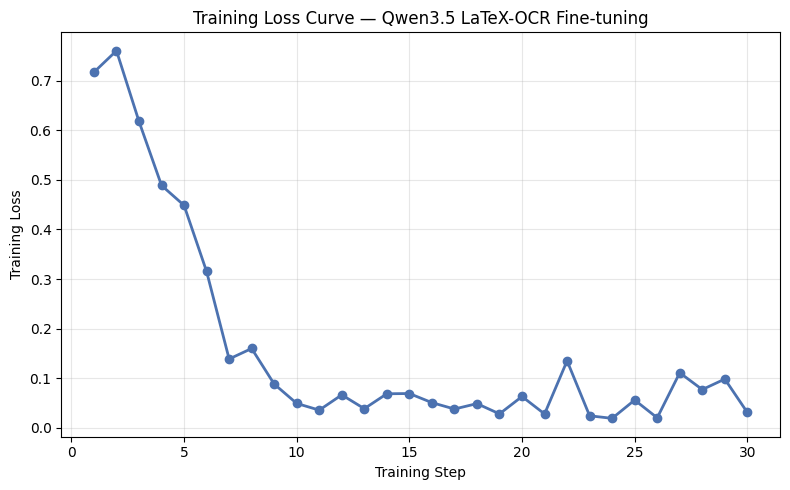

In [20]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
loss_history = pd.DataFrame([r for r in log_history if "loss" in r])
loss_history.to_csv("training_loss_history.csv", index = False)

plt.figure(figsize = (8, 5))
plt.plot(loss_history["step"], loss_history["loss"], marker = "o", linewidth = 2, color = "#4C72B0")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve — Qwen3.5 LaTeX-OCR Fine-tuning")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi = 150)
plt.show()


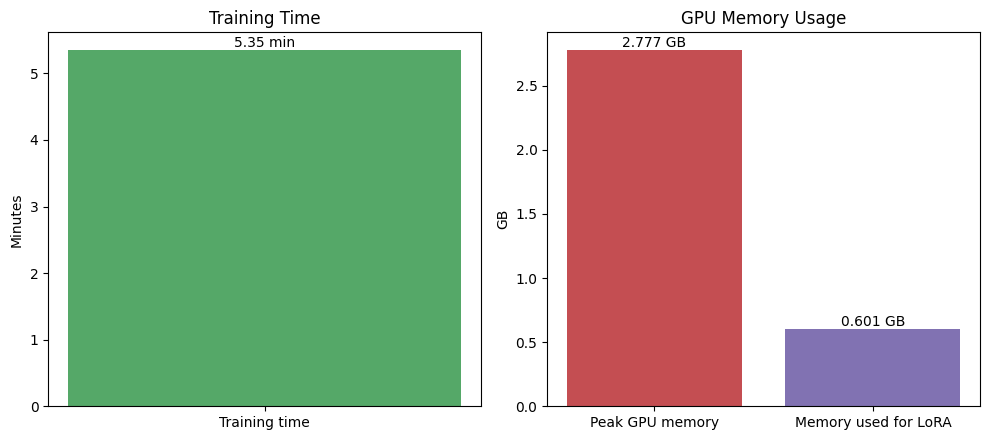

In [21]:
# Time & memory bar chart
fig, axes = plt.subplots(1, 2, figsize = (10, 4.5))

axes[0].bar(["Training time"], [trainer_stats.metrics["train_runtime"] / 60], color = "#55A868")
axes[0].set_ylabel("Minutes")
axes[0].set_title("Training Time")
axes[0].text(0, trainer_stats.metrics["train_runtime"] / 60,
             f"{trainer_stats.metrics['train_runtime']/60:.2f} min", ha = "center", va = "bottom")

axes[1].bar(["Peak GPU memory", "Memory used for LoRA"], [used_memory, used_memory_for_lora],
            color = ["#C44E52", "#8172B2"])
axes[1].set_ylabel("GB")
axes[1].set_title("GPU Memory Usage")
for i, v in enumerate([used_memory, used_memory_for_lora]):
    axes[1].text(i, v, f"{v} GB", ha = "center", va = "bottom")

plt.tight_layout()
plt.savefig("training_time_memory.png", dpi = 150)
plt.show()


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`.

In [22]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


H ^ { \prime } = \beta N \int d \lambda \left\{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \right\} .<|im_end|>


### Post Fine-tuning Evaluation — AFTER Fine-tuning

Now we run the exact same held-out `eval_samples` through the fine-tuned model, using the same `evaluate_on_samples` function, so the comparison is apples-to-apples.

In [23]:
finetuned_metrics, finetuned_df = evaluate_on_samples(model, tokenizer, eval_samples, tag = "fine-tuned (after fine-tuning)")
finetuned_df.head()


[fine-tuned (after fine-tuning)] samples=30 | mean CER=0.1101 | exact match=20.00% | mean BLEU=0.8834 | eval time=200.08s


,index,prediction,reference,cer,exact_match,bleu
0,0,s ^ { i j } = - \frac { 1 } { 8 \mu } \left[ \...,s ^ { i j } = - \frac 1 { 8 \mu } \left[ { \ca...,0.147727,0,0.887582
1,1,\Omega ( m ) = m \int _ { - \infty } ^ { \inft...,\Omega ( m ) = m \int _ { - \infty } ^ { \inft...,0.097826,0,0.906970
2,2,J _ { t o t } = \eta _ { 0 } / \lambda \epsilo...,J _ { t o t } = \eta _ { 0 } / \lambda \epsilo...,0.290323,0,0.826374
3,3,\Delta E _ { \mathrm { b a r e } } [ \chi ] = ...,\Delta E _ { \mathrm { b a r e } } [ \chi ] = ...,0.049107,0,0.943142
4,4,\mu _ { k } \propto \left( \frac { \eta } { \e...,\mu _ { k } \propto \left( \frac { \eta } { \e...,0.072727,0,0.921113


### Before vs. After Fine-tuning — Comparison

This is the summary table/chart you can drop straight into a resume, portfolio page, or README.

In [24]:
comparison_df = pd.DataFrame([baseline_metrics, finetuned_metrics]).set_index("tag")
comparison_df.to_csv("before_after_comparison.csv")
comparison_df


,num_samples,mean_cer,exact_match_accuracy,mean_bleu,eval_time_seconds
tag,,,,,
baseline (before fine-tuning),30,0.149683,0.0,0.855482,323.64
fine-tuned (after fine-tuning),30,0.110142,0.2,0.883442,200.08


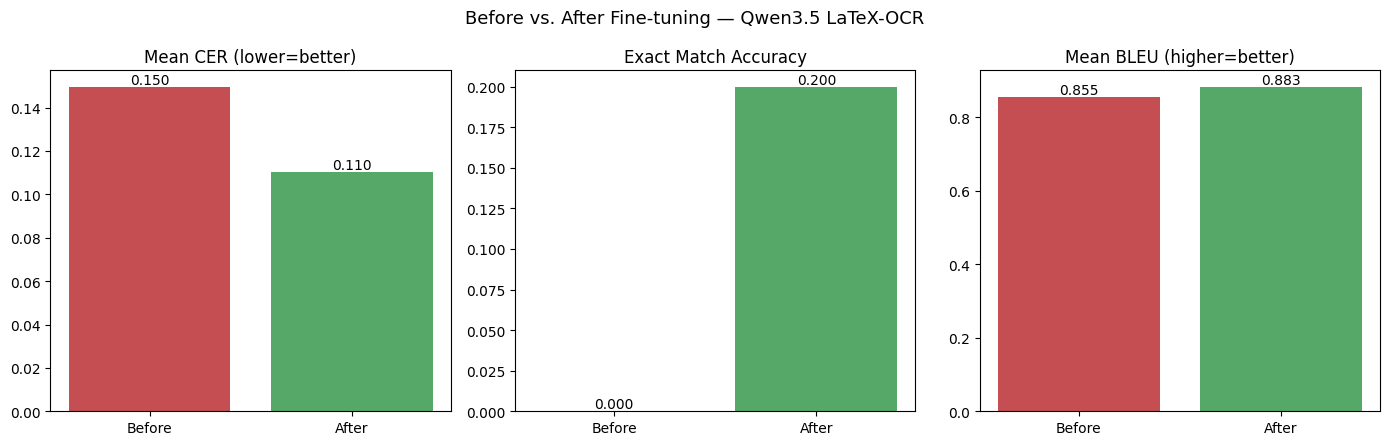

In [25]:
metrics_to_plot = ["mean_cer", "exact_match_accuracy", "mean_bleu"]
labels = ["Mean CER (lower=better)", "Exact Match Accuracy", "Mean BLEU (higher=better)"]

fig, axes = plt.subplots(1, 3, figsize = (14, 4.5))
for ax, metric, label in zip(axes, metrics_to_plot, labels):
    values = [baseline_metrics[metric], finetuned_metrics[metric]]
    bars = ax.bar(["Before", "After"], values, color = ["#C44E52", "#55A868"])
    ax.set_title(label)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha = "center", va = "bottom")

plt.suptitle("Before vs. After Fine-tuning — Qwen3.5 LaTeX-OCR", fontsize = 13)
plt.tight_layout()
plt.savefig("before_after_metrics.png", dpi = 150)
plt.show()


In [26]:
# A handful of qualitative before/after examples — useful screenshots for a portfolio/README
sample_compare = pd.DataFrame({
    "reference":            baseline_df["reference"],
    "prediction_before":    baseline_df["prediction"],
    "prediction_after":     finetuned_df["prediction"],
    "cer_before":           baseline_df["cer"],
    "cer_after":            finetuned_df["cer"],
})
sample_compare.to_csv("qualitative_before_after_examples.csv", index = False)
sample_compare.head(10)


,reference,prediction_before,prediction_after,cer_before,cer_after
0,s ^ { i j } = - \frac 1 { 8 \mu } \left[ { \ca...,$$s ^ { i j } = - \frac { 1 } { 8 \mu } \left[...,s ^ { i j } = - \frac { 1 } { 8 \mu } \left[ \...,0.176136,0.147727
1,\Omega ( m ) = m \int _ { - \infty } ^ { \inft...,$$\Omega ( m ) = m \int _ { - \infty } ^ { \in...,\Omega ( m ) = m \int _ { - \infty } ^ { \inft...,0.043478,0.097826
2,J _ { t o t } = \eta _ { 0 } / \lambda \epsilo...,$$J _ { t o t } = \eta _ { 0 } / \lambda \epsi...,J _ { t o t } = \eta _ { 0 } / \lambda \epsilo...,0.236559,0.290323
3,\Delta E _ { \mathrm { b a r e } } [ \chi ] = ...,$$\Delta E _ { \mathrm { b a r e } } [ \chi ] ...,\Delta E _ { \mathrm { b a r e } } [ \chi ] = ...,0.066964,0.049107
4,\mu _ { k } \propto \left( \frac { \eta } { \e...,$$\mu _ { k } \propto \left( \frac { \eta } { ...,\mu _ { k } \propto \left( \frac { \eta } { \e...,0.090909,0.072727
5,\Bigl ( { \rho ^ { k } } _ { i } \Bigr ) ^ { +...,$$\left( \rho ^ { k } { } _ { i } \right) ^ { ...,\left( \rho ^ { k } { } _ { i } \right) ^ { + ...,0.193103,0.317241
6,D _ { \mu } \rightarrow U D _ { \mu } U ^ { - ...,$$D _ { \mu } \rightarrow U D _ { \mu } U ^ { ...,D _ { \mu } \rightarrow U D _ { \mu } U ^ { - ...,0.109091,0.072727
7,H \ = \ G ^ { 2 } \cdot E _ { 2 } \ + \ E _ { ...,$$H = G ^ { 2 } \cdot E _ { 2 } + E _ { 4 } = ...,H \ = G ^ { 2 } \cdot E _ { 2 } \ + \ E _ { 4 ...,0.232323,0.020202
8,\delta _ { \epsilon } b = - \bar { \epsilon } ...,$$\delta _ { c } b = - \bar { \epsilon } \Gamm...,\delta _ { c } b = - \bar { \epsilon } \Gamma ...,0.066225,0.052980
9,\chi _ { a } = X _ { a } + i \left( \overline ...,$$\chi _ { a } = X _ { a } + i \left( \overlin...,\chi _ { a } = X _ { a } + i \left( \overline ...,0.160622,0.269430


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [27]:
model.save_pretrained("qwen_lora")  # Local saving
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving


['qwen_lora/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if True:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "qwen_lora", 
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)


==((====))==  Unsloth 2026.7.2: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }<|im_end|>
<|endoftext|>


### Saving to float16 for VLLM

Unsloth supports saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

**For the Streamlit app below, we need a merged 16-bit model** (LoRA adapters alone aren't directly loadable by a plain `transformers`/Streamlit app without Unsloth/PEFT set up identically). Set the flag below to `True` to save it locally.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit — set to True so we have a merged model ready for the Streamlit app
if True: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("bhaskar1707/unsloth_finetune", tokenizer, token = "###YOUR_HF_TOKEN###")


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...



Unsloth: Copying 1 files from cache to `unsloth_finetune`:   0%|          | 0/1 [00:00<?, ?it/s]
Unsloth: Copying 1 files from cache to `unsloth_finetune`: 100%|██████████| 1/1 [04:11<00:00, 251.85s/it]


Successfully copied all 1 files from cache to `unsloth_finetune`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 6432.98it/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [06:09<00:00, 369.96s/it]


Unsloth: Merge process complete. Saved to `/content/unsloth_finetune`


In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("bhaskar1707/qwen_finetune", tokenizer, token = "###YOUR_HF_TOKEN###")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("bhaskar1707/qwen_finetune", tokenizer, quantization_method = "f16", token = "###YOUR_HF_TOKEN###")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("bhaskar1707/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "###YOUR_HF_TOKEN###")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "bhaskar1707/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "###YOUR_HF_TOKEN###",
    )


<a name="Streamlit"></a>
### Package Everything for a Huggingface App

We now collect everything a Hugginface app needs into one folder — the merged model, tokenizer, all metrics (before/after), the loss curve, and the qualitative examples — then zip it up so you can download it or upload it wherever you'll host the app.

In [35]:
import json, shutil, os

APP_ASSETS_DIR = "streamlit_app_assets"
os.makedirs(APP_ASSETS_DIR, exist_ok = True)

# 1. Copy the merged 16-bit model + tokenizer (this is what the Streamlit app will load)
if os.path.exists("unsloth_finetune"):
    shutil.copytree("unsloth_finetune", os.path.join(APP_ASSETS_DIR, "model"), dirs_exist_ok = True)

# 2. Save all metrics as JSON (easy to render in Streamlit)
with open(os.path.join(APP_ASSETS_DIR, "metrics.json"), "w") as f:
    json.dump({"before_finetuning": baseline_metrics, "after_finetuning": finetuned_metrics}, f, indent = 2)

# 3. Copy CSVs and plots
for fname in ["training_loss_history.csv", "before_after_comparison.csv",
              "qualitative_before_after_examples.csv", "training_loss_curve.png",
              "training_time_memory.png", "before_after_metrics.png"]:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(APP_ASSETS_DIR, fname))

# 4. Zip everything up
shutil.make_archive("streamlit_app_assets", "zip", APP_ASSETS_DIR)
print("Packaged assets in:", APP_ASSETS_DIR)
print("Zip file ready at: streamlit_app_assets.zip")

# In Colab, uncomment to trigger a download:
# from google.colab import files
# files.download("streamlit_app_assets.zip")


Packaged assets in: streamlit_app_assets
Zip file ready at: streamlit_app_assets.zip


In [36]:
# In Colab, uncomment to trigger a download:
from google.colab import files
files.download("streamlit_app_assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>